<div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 40px; margin-top: 0;">
    <div style="flex: 0 0 auto; margin-left: 0; margin-bottom: 0; margin-top: 0;">
        <img src="./pics/UCSD Logo.png" alt="UCSD Logo" style="width: 179px; margin-bottom: 0px; margin-top: 20px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/sdsc-logo.png" alt="SDSC Logo" style="width: 300px; margin-bottom: 0px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/usgs-logo.png" alt="USGS Logo" style="width: 100px; margin-bottom: 0px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/wstc-logo.png" alt="WSTC Logo" style="width: 100px; height: 100px; margin-bottom: 0px;">
    </div>
</div>

<h1 style="text-align: center; font-size: 48px; margin-top: 0;">3D Elevation Program (3DEP)</h1>

- **Team Name: Dry-shRub**
- **Team Members:**
    - Uzair Gheewala
    - Sean Harmon

1. In the `3DEP.ipynb` notebook, we previously selected a random image in California. 

For this Data Challenge, you will work with data located from [D. L. Bliss State Park](https://en.wikipedia.org/wiki/D._L._Bliss_State_Park), one of our areas of interest (AOI). Use 3DEP data in Google Earth Engine to identify and select a 3DEP image within D. L. Bliss.

Use coordinates within the following bounding box (WGS84 lon/lat):

* Min X (lon): -120.1018846
* Min Y (lat): 38.99274873
* Max X (lon): -120.0899834
* Max Y (lat): 39.0020357

In [2]:
import ee
import geemap
import folium
import numpy as np
import matplotlib.pyplot as plt

ee.Authenticate()
ee.Initialize(project="shrubwise-dc-488219")

In [3]:
threedep_10m = ee.ImageCollection("USGS/3DEP/10m_collection")

print("Total images in collection:", threedep_10m.size().getInfo())
first_img = threedep_10m.first()
print("\nFirst image info (short):")
print(first_img.getInfo()['properties'].keys())

band_names = first_img.bandNames().getInfo()
print("Band names:", band_names)

Total images in collection: 1447

First image info (short):
dict_keys(['system:time_start', 'system:footprint', 'system:time_end', 'system:asset_size', 'system:index'])
Band names: ['elevation']


In [4]:
aoi = ee.Geometry.Rectangle(
    [-120.1018846, 38.99274873, -120.0899834, 39.0020357],
    geodesic=False
)

center_lon = (-120.1018846 + -120.0899834) / 2
center_lat = (38.99274873 + 39.0020357) / 2
pt = ee.Geometry.Point([center_lon, center_lat])

hits = threedep_10m.filterBounds(pt)
print("3DEP images intersecting AOI point:", hits.size().getInfo())

elev_img = ee.Image(hits.first()).select("elevation").rename("elevation")

print("Band names:", elev_img.bandNames().getInfo())
print("Scale (m):", elev_img.projection().nominalScale().getInfo())
print("Projection:", elev_img.projection().getInfo())

3DEP images intersecting AOI point: 1
Band names: ['elevation']
Scale (m): 10.3073602743545
Projection: {'type': 'Projection', 'crs': 'EPSG:4269', 'transform': [9.259259269220167e-05, 0, -121.00055555619338, 0, -9.259259277537894e-05, 39.00055555659456]}


2. Using the DL Bliss image, visualize the elevation, slope and aspect

In [5]:
slope_img = ee.Terrain.slope(elev_img).rename("slope")
aspect_img = ee.Terrain.aspect(elev_img).rename("aspect")

roi = aoi.buffer(2000).bounds()
elev_clip = elev_img.clip(roi)
slope_clip = slope_img.clip(roi)
aspect_clip = aspect_img.clip(roi)

elev_vis = {
    "min": 1800,
    "max": 2300,
    "palette": ["0000ff", "00ffff", "00ff00", "ffff00", "ff0000", "ffffff"]
}

slope_vis = {
    "min": 0,
    "max": 60,
    "palette": ["ffffff", "fff7bc", "fec44f", "fe9929", "ec7014", "cc4c02", "8c2d04"]
}

aspect_vis = {
    "min": 0,
    "max": 360,
    "palette": ["ff0000", "ffff00", "00ff00", "00ffff", "0000ff", "ff00ff", "ff0000"]
}

def add_ee_layer(m, ee_image, vis_params, name):
    map_id = ee_image.getMapId(vis_params)
    folium.TileLayer(
        tiles=map_id["tile_fetcher"].url_format,
        attr="Google Earth Engine",
        name=name,
        overlay=True,
        control=True
    ).add_to(m)

m = folium.Map(location=[center_lat, center_lon], zoom_start=14)

add_ee_layer(m, elev_clip, elev_vis, "Elevation")
add_ee_layer(m, slope_clip, slope_vis, "Slope")
add_ee_layer(m, aspect_clip, aspect_vis, "Aspect")

folium.GeoJson(aoi.getInfo(), name="AOI").add_to(m)
folium.LayerControl().add_to(m)

m

3. Compute and plot a histogram and basic summary statistics (mean, median, min, max) for the elevation of your selected image.

3DEP elevation summary (5km x 5km):
  valid_pixel_count: 183326
  mean: 2012.988736019557
  median: 1909.9238798730814
  min: 1897.411865234375
  max: 2795.1962890625
  stdDev: 175.5643310163784
  p05: 1897.5545039698193
  p25: 1897.5545039698193
  p75: 2061.9852814232595
  p95: 2437.9906827338837


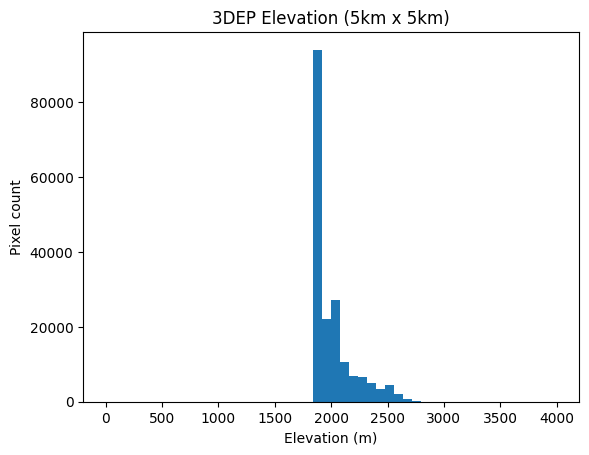

In [6]:
center_pt = ee.Geometry.Point([center_lon, center_lat])
roi_5km = center_pt.buffer(2500).bounds()

stats_reducer = (
    ee.Reducer.count()
      .combine(ee.Reducer.mean(), sharedInputs=True)
      .combine(ee.Reducer.median(), sharedInputs=True)
      .combine(ee.Reducer.min(), sharedInputs=True)
      .combine(ee.Reducer.max(), sharedInputs=True)
      .combine(ee.Reducer.stdDev(), sharedInputs=True)
      .combine(ee.Reducer.percentile([5, 25, 75, 95]), sharedInputs=True)
)

stats = elev_img.reduceRegion(
    reducer=stats_reducer,
    geometry=roi_5km,
    scale=10,
    maxPixels=1e9,
    bestEffort=True
).getInfo()

report = {
    "valid_pixel_count": stats.get("elevation_count"),
    "mean": stats.get("elevation_mean"),
    "median": stats.get("elevation_median"),
    "min": stats.get("elevation_min"),
    "max": stats.get("elevation_max"),
    "stdDev": stats.get("elevation_stdDev"),
    "p05": stats.get("elevation_p5"),
    "p25": stats.get("elevation_p25"),
    "p75": stats.get("elevation_p75"),
    "p95": stats.get("elevation_p95"),
}

print("3DEP elevation summary (5km x 5km):")
for k, v in report.items():
    print(f"  {k}: {v}")

hist = elev_img.reduceRegion(
    reducer=ee.Reducer.fixedHistogram(0, 4000, 50),
    geometry=roi_5km,
    scale=10,
    maxPixels=1e9,
    bestEffort=True
).get("elevation").getInfo()

bin_left = np.array([b[0] for b in hist], dtype=float)
counts = np.array([b[1] for b in hist], dtype=float)
bin_width = (4000 - 0) / 50
bin_centers = bin_left + bin_width / 2

plt.figure()
plt.bar(bin_centers, counts, width=bin_width)
plt.title("3DEP Elevation (5km x 5km)")
plt.xlabel("Elevation (m)")
plt.ylabel("Pixel count")
plt.show()